# CRMLS Sold Data Analysis

In [ ]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

## Monthly Dataset Aggregation

In [ ]:
# Get all CRMLSSold files
sold_data = glob.glob('**/CRMLSSold*.csv',recursive=True)

df_list = []
for file in sold_data:
    df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)
    print(f"Rows before aggregation: {len(df)}")
    df_list.append(df)
sold_df = pd.concat(df_list, ignore_index=True)

print(f'Rows after aggregation: {len(sold_df)}')

# Filter to residential
print(f"Rows before Residential Filter: {len(sold_df)}")
sold_df = sold_df[sold_df['PropertyType'] == "Residential"]
print(f"Rows after Residential Filter: {len(sold_df)}")

# Save to csv 
sold_df.to_csv('CRMLSSoldResidential.csv', index=False)

C:\Users\caden\AppData\Local\Temp\ipykernel_30104\2434614765.py:6: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: FireplaceYN, 3: OriginatingSystemName, 4: OriginatingSystemSubName, 5: BuyerAgencyCompensationType, 6: latfilled, 7: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)


Rows before aggregation: 735172
Rows before aggregation: 7000
Rows before aggregation: 7000
Rows before aggregation: 17976
Rows before aggregation: 19925
Rows before aggregation: 23276


C:\Users\caden\AppData\Local\Temp\ipykernel_30104\2434614765.py:6: DtypeWarning: Columns (0: WaterfrontYN, 1: ElementarySchool, 2: BuilderName, 3: CoBuyerAgentFirstName, 4: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)


Rows before aggregation: 24640
Rows before aggregation: 26487
Rows before aggregation: 24328
Rows before aggregation: 26240
Rows before aggregation: 24558
Rows before aggregation: 21267
Rows before aggregation: 23274
Rows before aggregation: 20279
Rows before aggregation: 20241
Rows before aggregation: 18738
Rows before aggregation: 18702
Rows before aggregation: 21445
Rows before aggregation: 23262
Rows before aggregation: 23154
Rows before aggregation: 22883


C:\Users\caden\AppData\Local\Temp\ipykernel_30104\2434614765.py:6: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)


Rows before aggregation: 23646
Rows before aggregation: 22972
Rows before aggregation: 22443
Rows before aggregation: 23233
Rows before aggregation: 19088
Rows before aggregation: 20538
Rows after aggregation: 1281767
Rows before Residential Filter: 1281767
Rows after Residential Filter: 1102758


## Dataset Structuring and Validation

### Dataset Understanding

In [ ]:
sold_df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,ListAgentEmail,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,Wood,False,NaN,NaN,NaN,NaN,1156843715,2026-02-27,...,NaN,25900.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,NaN
1,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1100000.0,1155620121,2026-02-27,...,NaN,5000.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,NaN
2,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,False,NaN,NaN,False,999000.0,1155350576,2026-02-27,...,NaN,12005.0,NaN,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN,NaN
3,Newport,Newport,NaN,False,NaN,NaN,False,525000.0,1155192177,2026-02-24,...,0.0,18730.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,NaN
4,Mrmls,SierraNorthValley,NaN,True,NaN,NaN,False,299000.0,1155179209,2026-02-27,...,468.0,871.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Number of rows and columns
sold_df.shape

(1102758, 84)

In [ ]:
# Look at dataframe columns
sold_df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName',
       'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType',
       'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName',
       'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId',
       'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal',
       'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear',
       '

In [ ]:
# Review column data types
sold_df.info()

<class 'pandas.DataFrame'>
Index: 1102758 entries, 0 to 1281765
Data columns (total 84 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   BuyerAgentAOR                 961683 non-null   str    
 1   ListAgentAOR                  964221 non-null   str    
 2   Flooring                      708570 non-null   str    
 3   ViewYN                        1007136 non-null  object 
 4   WaterfrontYN                  669 non-null      object 
 5   BasementYN                    21750 non-null    object 
 6   PoolPrivateYN                 1004292 non-null  object 
 7   OriginalListPrice             1100667 non-null  float64
 8   ListingKey                    1102758 non-null  int64  
 9   CloseDate                     1102758 non-null  str    
 10  ClosePrice                    1102752 non-null  float64
 11  ListAgentFirstName            1094094 non-null  str    
 12  ListAgentLastName             1102653 non-nu

### Missing Value Analysis

In [ ]:
# Identify high-missing columns
sold_df.isnull().sum()

BuyerAgentAOR                   141075
ListAgentAOR                    138537
Flooring                        394188
ViewYN                           95622
WaterfrontYN                   1102089
                                ...   
ListAgentEmail                   27150
BuyerAgencyCompensationType     964350
BuyerAgencyCompensation         964383
latfilled                       911106
lonfilled                       911106
Length: 84, dtype: int64

In [ ]:
# Calculate missing counts and percentages per column
null_counts = sold_df.isnull().sum()
null_pct = (sold_df.isnull().sum() / len(sold_df)) * 100

null_report = pd.DataFrame({'Counts': null_counts, 'Percentage': null_pct})
high_missing = null_report[null_report['Percentage'] > 90]
print(high_missing)

                               Counts  Percentage
WaterfrontYN                  1102089   99.939334
BasementYN                    1081008   98.027672
FireplacesTotal               1102758  100.000000
AboveGradeFinishedArea        1102758  100.000000
TaxAnnualAmount               1102758  100.000000
BuilderName                   1049109   95.135016
TaxYear                       1102758  100.000000
BuildingAreaTotal             1026189   93.056591
ElementarySchoolDistrict      1102758  100.000000
CoBuyerAgentFirstName         1002888   90.943616
BelowGradeFinishedArea        1096464   99.429249
BusinessType                  1102758  100.000000
CoveredSpaces                 1102758  100.000000
LotSizeDimensions             1049337   95.155691
MiddleOrJuniorSchoolDistrict  1102758  100.000000
OriginatingSystemName         1044804   94.744631
OriginatingSystemSubName      1044804   94.744631


In [ ]:
# Drop columns
print(f"Number of columns before dropping: {sold_df.shape[1]}")
threshold = 0.1 * len(sold_df)
sold_df.dropna(thresh=threshold, axis=1, inplace=True)
print(f"Number of columns after dropping: {sold_df.shape[1]}")


Number of columns before dropping: 84
Number of columns after dropping: 67


### Numeric Distribution Review


In [ ]:
# Analyze distribution of key numeric fields
core_numeric = ['ClosePrice', 'ListPrice','OriginalListPrice','LivingArea','LotSizeAcres','BedroomsTotal','BathroomsTotalInteger','DaysOnMarket','YearBuilt']
sold_df[core_numeric].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,3.393010e+05,3.393010e+05,3.388020e+05,3.393010e+05,3.111930e+05,339301.000000,339248.000000,339301.000000,339301.000000
mean,9.031845e+05,8.981091e+05,9.865938e+05,1.774322e+03,5.145106e+01,3.118252,2.395457,35.280382,1978.288048
std,4.699339e+05,4.657970e+05,7.125271e+06,2.922773e+04,1.083312e+04,1.015385,0.961338,51.468052,25.865330
min,0.000000e+00,5.250000e+02,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
25%,5.600000e+05,5.599990e+05,5.699000e+05,1.218000e+03,1.192000e-01,2.000000,2.000000,7.000000,1960.000000
50%,7.850000e+05,7.880000e+05,7.970000e+05,1.584000e+03,1.639000e-01,3.000000,2.000000,18.000000,1979.000000
75%,1.160000e+06,1.150000e+06,1.175000e+06,2.080000e+03,2.548000e-01,4.000000,3.000000,46.000000,1997.000000
max,2.380000e+06,1.150000e+07,1.390000e+09,1.702132e+07,4.187292e+06,45.000000,175.000000,12430.000000,2026.000000


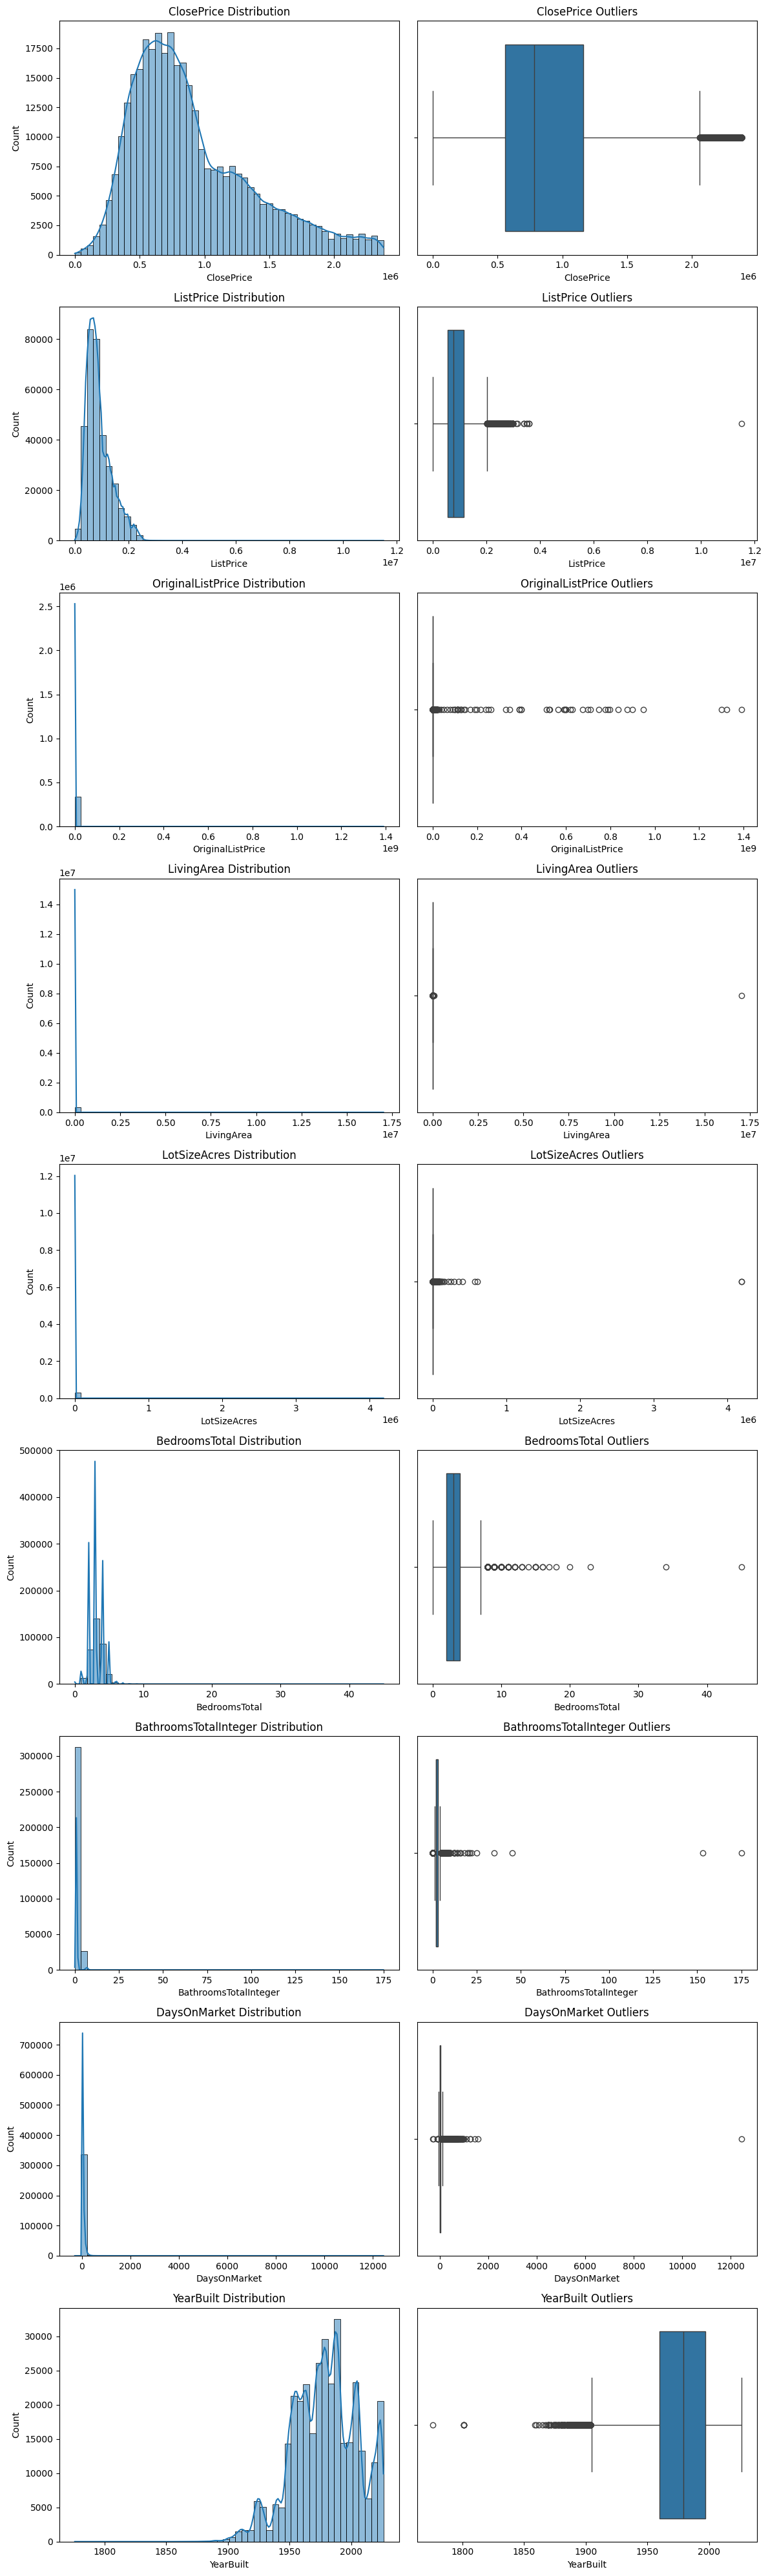

In [ ]:
# Graphs
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(12,40))

for i, col in enumerate(core_numeric):
    # Histogram
    sns.histplot(sold_df[col],bins=50,kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(x=sold_df[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} Outliers')
plt.tight_layout()
plt.show()

### Mortgage Rate Enrichment

In [ ]:
# Fetch mortgage rate data
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['DATE'])
mortgage.columns = ['date','rate_30yr_fixed']

# Resample weekly rates to montly averages
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed'].mean().reset_index()
)
# Create a matching year_month key on the MLS datasets
sold_df['year-month'] = pd.to_datetime(sold_df['CloseDate']).dt.to_period('M')
sold_with_rates_df = sold_df.merge(mortgage_monthly, on='year_month',how='left')
print(sold_with_rates_df['rate_30yr_fixed']).isnull().sum()

# Preview
print(sold_with_rates_df[['CloseDate','year_month','ClosePrice','rate_30yr_fixed']].head())


## Data Cleaning and Preparation

In [ ]:
# Convert data fields to datetime format
sold_with_rates_df['CloseDate'] = pd.to_datetime(sold_with_rates_df['CloseDate'])
sold_with_rates_df['ListingContractDate'] = pd.to_datetime(sold_with_rates_df['ListingContractDate'])
sold_with_rates_df['PurchaseContractDate'] = pd.to_datetime(sold_with_rates_df['PurchaseContractDate'])
sold_with_rates_df['ContractStatusChangeDate'] = pd.to_datetime(sold_with_rates_df['ContractStatusChangeDate'])


In [ ]:
# Check for duplicates
sold_with_rates_df[sold_with_rates_df.duplicated(subset='ListingKey')]
sold_with_rates_df = sold_with_rates_df.drop_duplicates(subset=['ListingKey'], keep='last') # Keep the most recent property with the listing key

In [ ]:
# Drop rows if missing critical value
must_columns = ['ListingKey', 'ClosePrice', 'CloseDate', 'City']
sold_with_rates_df = sold_with_rates_df.dropna(subset=must_columns)

In [ ]:
# Fill in missing counts with '0'
zero_fill_cols = ['GarageSpaces', 'ParkingTotal', 'FireplacesTotal']

for col in zero_fill_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(0)

# Fill in missing Yes/No features with 'No'
fill_no_cols = ['PoolPrivateYN', 'ViewYN', 'CoolingYN', 'HeatingYN']
for col in fill_no_cols:
    if col in sold_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(False)

# Fill in missing categorical data with "Unknown"
cat_fill_cols = ['ArchitectureStyle', 'Heating', 'Cooling', 'WaterSource']
for col in cat_fill_cols:
    if col in sold_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna('Unknown')

# Fill in missing numerical values
num_fill_cols = ['LotSizeArea', 'YearBuilt']
for col in num_fill_cols:
    if col in sold_df.columns:
        col_median = sold_df[col].median()
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(col_median)


In [ ]:
# Drop missing Living Area
sold_with_rates_df = sold_with_rates_df.dropna(subset='LivingArea')
# Filter out where Living Area is less than 0
sold_with_rates_df = sold_with_rates_df[sold_df['LivingArea'] > 0]

In [ ]:
# Remove rows with invalid numeric values
sold_with_rates_df = sold_with_rates_df[(sold_with_rates_df['ClosePrice'] > 0) & (sold_with_rates_df['LivingArea'] > 0) & (sold_with_rates_df['DaysOnMarket'] >= 0) & (sold_with_rates_df['Bedrooms'] >= 0) & (sold_with_rates_df['Bathrooms'] >= 0)]

In [ ]:
# Data consistency checks
sold_with_rates_df['listing_after_close_flag'] = sold_with_rates_df['ListingContractDate'] < sold_with_rates_df['PurchaseContractDate']
sold_with_rates_df['purchase_after_close_flag'] = sold_with_rates_df['PurchaseContractDate'] > sold_with_rates_df['ListingContractDate']
sold_with_rates_df['negative_timeline_flag'] = sold_with_rates_df['DaysOnMarket'] < 0


In [ ]:
# Geographic Data Checks
sold_with_rates_df['missing_coords'] = sold_with_rates_df['Latitude'].isnull() | sold_with_rates_df['Longitude'].isnull()
sold_with_rates_df['sentinel_coords'] = (sold_with_rates_df['Latitude'] == 0) | (sold_with_rates_df['Longitude'] == 0)
sold_with_rates_df['cal_coords'] = sold_with_rates_df['Longitude'] > 0
sold_with_rates_df

## Feature Engineering and Market Metrics

In [ ]:
sold_df['PriceRatio'] = sold_df['ClosePrice'] / sold_df['OriginalListPrice']
sold_df['PricePerSqFt'] = sold_df['ClosePrice'] / sold_df['LivingArea']
sold_df['Year'] = sold_df['CloseDate'].dt.year
sold_df['Month'] = sold_df['CloseDate'].dt.month
sold_df['YrMo'] = sold_df['CloseDate'].dt.to_period('M').astype(str)

## Outlier Detection and Data Quality

In [ ]:
Q1 = sold_df['ClosePrice'].quantile(0.25)
Q3 = sold_df['ClosePrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1- 1.5 * IQR
upper = Q3 + 1.5 * IQR

sold_df = sold_df[(sold_df['ClosePrice'] >= lower) & (sold_df['ClosePrice'] <= upper)]

## Export to CSV for Tableau